# Tutorial 1.1: Top-Hat Synthetic Catalogs

This notebook is a cleaner companion to Tutorial 1. It keeps the top-hat jet model, but fixes the catalogue generation logic so the number of simulated events comes from the Monte Carlo population the model sees, not from a shortcut based on the observed rate.

We cover:

1. The top-hat geometry and the role of theta_c
2. How to count the events seen by the Monte Carlo
3. How to generate GBM-like observables
4. How to generate observables with a custom sensitivity
5. How to keep E_iso and theta_c consistent in the catalogue

## Imports

In [60]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import inf
from pathlib import Path

import emcee

import notebook_setup
import src.init

from src.montecarlo import DEFAULT_LIMITS
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    create_log_probability_function,
    check_and_resume_mcmc,
    run_mcmc,
)
from src.top_hat.geometric_eff import geometric_efficiency_fixed, geometric_efficiency_flat, create_geometric_efficiency_lognormal_interpolator
from src.top_hat.plot import TopHatPlotter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Why this tutorial exists

The top-hat model has a simple angular structure: a jet is bright only inside its opening angle. For a flat top-hat distribution, theta_c is drawn uniformly between 1 deg and theta_c_max. For a universal model, every jet shares the same theta_c.

For the energy column, we keep the distinction explicit:

- E_iso is the isotropic-equivalent energy inferred from the luminosity draw
- E_jet is the collimation-corrected energy, which depends on theta_c through 1 - cos(theta_c)

That dependence is the part that needs care in the non universal top-hat case.

## Setup and Priors

We keep the same flat-prior model as Tutorial 1. The only change is that the catalogue section later on uses a reusable event-count helper.

In [61]:
CUSTOM_EFFICIENCY = 0.6 # the GBM duty cycle + FOV change it to whatever you wish 

INPUT_LIMITS = DEFAULT_LIMITS.copy() # Change this to whatever you wish

In [62]:
datafiles   = Path('../datafiles')
output_dir  = src.init.create_run_dir('tutorial1_tophat_flat')

params = {
    "alpha"       : -0.67,
    "beta_s"      : -2.59,
    "n"           : 2,
    "z_model"     : 'fiducial_Hrad_A1.0'  # Change to 'fiducial_Hrad_TEST_A1.0' to use Tutorial 0 samples
}

default_params, _, data_dict = src.init.initialize_simulation(datafiles, params=params)

PARAM_NAMES = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E', 'theta_c_max', 'fj']
N_PARAMS    = len(PARAM_NAMES)

k_interpolator = create_k_interpolator() # Used for top-hat k-factor

Loading existing directory  : Output_files/tutorial1_tophat_flat
Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Computed total merger rate: 360832.5 yr^-1 (local R_0 = 112.0 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year


## MCMC and event accounting

The MCMC setup can stay the same as Tutorial 1. The important part for this notebook is the event-count helper below: it computes how many bursts the Monte Carlo actually needs to draw before any detection cuts are applied.

In [63]:
from scipy.stats import lognorm

BURN_IN = 200

geo_interp = create_geometric_efficiency_lognormal_interpolator() # used for log-normal geometric efficiency
def expected_tophat_events(theta, params_in, n_years=4, theta_c_mode='flat'):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_value, fj = theta
    gbm_eff = CUSTOM_EFFICIENCY

    if theta_c_mode == 'flat':
        geometric_efficiency = geometric_efficiency_flat(theta_c_value)
    elif theta_c_mode == 'fixed':
        geometric_efficiency = geometric_efficiency_fixed(theta_c_value)
    elif theta_c_mode == 'log_normal':
        geometric_efficiency = geo_interp(theta_c_value)
    else:
        raise ValueError("theta_c_mode must be 'flat', 'fixed', or 'log_normal')")

    # number of years * BNS/yr * fraction within theta_c * GBM efficiency * fraction of one-sided jets
    available_events = n_years * len(params_in.z_arr) * geometric_efficiency * gbm_eff * fj
    n_events = max(1, int(np.ceil(available_events))) # make sure we have at least 1 event to simulate
    return n_events, geometric_efficiency

def draw_tophat_geometry(rng, n_events, theta_c_mode, theta_c_value, theta_c_min=1.0):
    if theta_c_mode     == 'flat':
        theta_c_deg = rng.uniform(theta_c_min, theta_c_value, size=n_events)
    elif theta_c_mode   == 'fixed':
        theta_c_deg = np.full(n_events, theta_c_value, dtype=float)
    elif theta_c_mode   == 'log_normal': # draw from a lognorm between 1 and 45 
        sigma_theta_c = 0.5 
        # Match efficiency raw calc: median = theta_c_value, sigma is in log10 space
        mu = np.log(theta_c_value)
        sigma = sigma_theta_c * np.log(10)
        
        shape = sigma
        scale = np.exp(mu)
        
        # Proper truncation using Inverse Transform Sampling
        cdf_min = lognorm.cdf(theta_c_min, s=shape, scale=scale)
        cdf_max = lognorm.cdf(45.0, s=shape, scale=scale)
        
        # Uniform samples in the valid truncated CDF range
        u = rng.uniform(cdf_min, cdf_max, size=n_events)
        
        # Map back to theta values
        theta_c_deg = lognorm.ppf(u, s=shape, scale=scale)
    else:
        raise ValueError("theta_c_mode must be 'flat', 'fixed', or 'log_normal'")

    theta_view_deg = np.degrees(np.arccos(rng.uniform(0.0, 1.0, size=n_events)))
    on_axis = theta_view_deg <= theta_c_deg
    return theta_view_deg, theta_c_deg, on_axis

def make_tophat_catalog(theta, params_in, distances, k_interpolator, 
                        n_years=4, limits=INPUT_LIMITS, theta_c_mode='flat', 
                        theta_c_min=1.0, duration_s=1.0, epsilon_factor = 0.3, seed=1234):
    
    rng = np.random.default_rng(seed)
    n_events, geo_eff = expected_tophat_events(theta, params_in, n_years=n_years, theta_c_mode=theta_c_mode)
    mc = simplified_montecarlo(theta, n_events, params_in, distances, k_interpolator, rng=rng)
    theta_view_deg, theta_c_deg, on_axis = draw_tophat_geometry(rng, n_events, theta_c_mode, theta[4], theta_c_min=theta_c_min)
    # on_axis is taken care of in simplified_montecarlo

    observed_flux   = mc['p_flux']

    trigger_mask, analysis_mask = apply_detection_cuts(
        observed_flux,
        mc['E_p_obs'],
        pflux_min=limits['F_LIM'],
        epeak_range=(limits['EP_LIM_LOWER'], limits['EP_LIM_UPPER']),
    )

    print(sum(trigger_mask))

    final_mask = analysis_mask
    if np.sum(final_mask) == 0:
        return pd.DataFrame(columns=[
            'z', 'theta_view_deg', 'theta_c_deg', 'p_flux_ph_cm2_s', 'E_p_obs_keV',
            'log_10_E_iso_erg', 'log_10_E_jet_one_sided_erg'
        ])

    e_iso_erg           = mc['L_p_obs'] * duration_s * epsilon_factor #which is the median of the peak flux to average flux ratios in the GBM sample
    e_jet_one_sided_erg = e_iso_erg * (1.0 - np.cos(np.deg2rad(theta_c_deg)))

    catalog = pd.DataFrame({
        'z': mc['z_arr'][final_mask],
        'theta_view_deg': theta_view_deg[final_mask],
        'theta_c_deg': theta_c_deg[final_mask],
        'p_flux_ph_cm2_s': observed_flux[final_mask],
        'E_p_obs_keV': mc['E_p_obs'][final_mask],
        'log_10_E_iso_erg': np.log10(e_iso_erg[final_mask]),
        'log_10_E_jet_one_sided_erg': np.log10(e_jet_one_sided_erg[final_mask]),
    })

    catalog = catalog.sort_values(['z', 'theta_view_deg']).reset_index(drop=True)
    catalog.attrs['n_events_simulated'] = n_events
    catalog.attrs['geometric_efficiency'] = geo_eff
    catalog.attrs['theta_c_mode'] = theta_c_mode
    return catalog

## Load a representative posterior sample

The catalogue examples below use the posterior median if a chain exists, otherwise they fall back to a representative parameter vector so the notebook remains usable even before the MCMC is run.

In [64]:
distances = compute_luminosity_distance(default_params.z_arr) # precompute distances for efficiency

theta_demo      = np.array([3.0, 3.0, 3.0, 0.5, 10.0, 0.5])
samples         = None
backend_path    = output_dir / 'emcee.h5'

if backend_path.exists():
    backend = emcee.backends.HDFBackend(backend_path)
    try:
        samples = backend.get_chain(discard=BURN_IN, thin=10, flat=True)
        if len(samples) > 0:
            theta_demo = np.median(samples, axis=0)
    except Exception:
        pass

print(f'Using theta_demo = {theta_demo}')
print(f'Example geometric efficiency = {expected_tophat_events(theta_demo, default_params)[1]:.4f}')

Using theta_demo = [ 2.93199032  2.81994773  3.49967336  0.479779   11.30958184  0.5466654 ]
Example geometric efficiency = 0.0071


## GBM-like catalogue

This is the case you asked for first: draw the Monte Carlo population for the top-hat model, then keep only the events that survive the GBM-like cuts. The event count comes from the simulated population size, not from the observed catalogue rate.

For the flat top-hat model, theta_c is sampled event by event from 1 deg to theta_c_max.

In [70]:
N_YEARS = 10
gbm_catalog = make_tophat_catalog(
    theta=theta_demo,
    params_in=default_params,
    distances=distances,
    k_interpolator=k_interpolator,
    n_years=N_YEARS,
    limits=DEFAULT_LIMITS,
    theta_c_mode='flat',
    theta_c_min=1.0,
    duration_s=1.0,
    seed=42,
)

display_cols = ['z', 'theta_view_deg', 'theta_c_deg', 'log_10_E_iso_erg', 'log_10_E_jet_one_sided_erg']
print(f'GBM-like detected events: {len(gbm_catalog)}')
simulated_draws = gbm_catalog.attrs.get('n_events_simulated', 'n/a')
print(f'Simulated draws: {simulated_draws}')
gbm_catalog[display_cols].head(10)

gbm_path = output_dir / 'tophat_catalog_gbm.csv'
gbm_catalog.to_csv(gbm_path, index=False)
print(f'Saved GBM-like catalogue to {gbm_path}')

210
GBM-like detected events: 209
Simulated draws: 8368
Saved GBM-like catalogue to Output_files/tutorial1_tophat_flat/tophat_catalog_gbm.csv


## Custom sensitivity catalogue

The same helper can be reused with different detector cuts. That makes the notebook suitable for the GBM case above and for a custom sensitivity curve or a different instrument threshold.

If you are using a universal opening angle model, switch theta_c_mode to 'fixed' and pass a theta_c value instead of theta_c_max.

In [ ]:
CUSTOM_LIMITS = {
    'F_LIM': 1.0,
    'EP_LIM_LOWER': 20,
    'EP_LIM_UPPER': 20_000,
}

custom_catalog = make_tophat_catalog(
    theta=theta_demo,
    params_in=default_params,
    distances=distances,
    k_interpolator=k_interpolator,
    n_years=10,
    limits=CUSTOM_LIMITS,
    theta_c_mode='flat',
    theta_c_min=1.0,
    duration_s=1.0,
    seed=123,
)

print(f'Custom-sensitivity detected events: {len(custom_catalog)}')
custom_catalog[['z', 'theta_view_deg', 'theta_c_deg', 'log_10_E_iso_erg', 'log_10_E_jet_one_sided_erg']].head(10)

custom_path = output_dir / 'tophat_catalog_custom_sensitivity.csv'
custom_catalog.to_csv(custom_path, index=False)
print(f'Saved custom-sensitivity catalogue to {custom_path}')

1036
Custom-sensitivity detected events: 1034
Saved custom-sensitivity catalogue to Output_files/tutorial1_tophat_flat/tophat_catalog_custom_sensitivity.csv


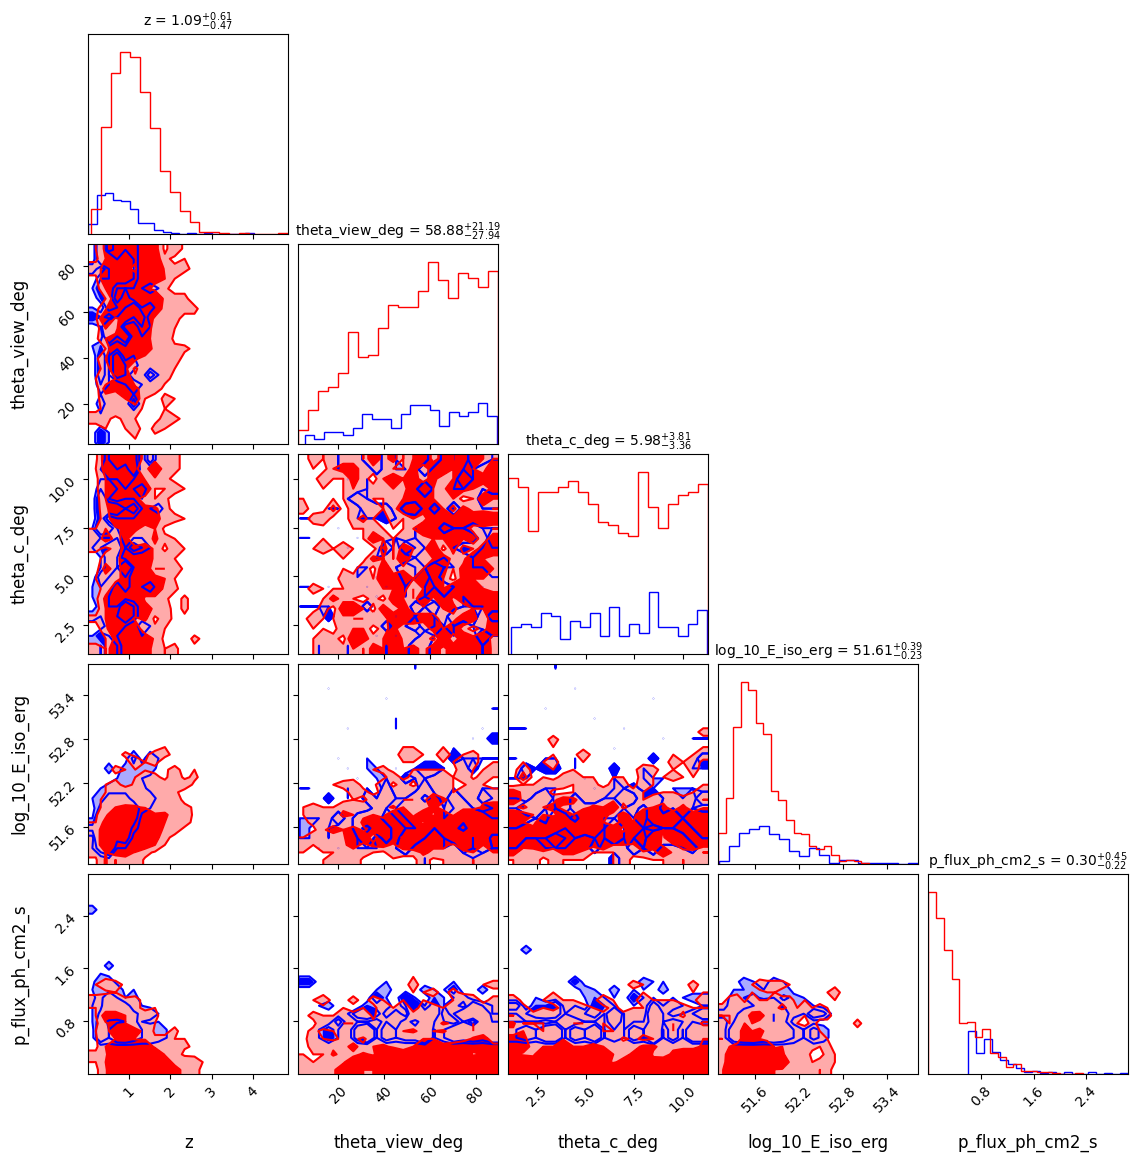

In [74]:
# corner plot comparing the two catalogs
import corner

observables = ['z', 'theta_view_deg', 'theta_c_deg', 'log_10_E_iso_erg', 'p_flux_ph_cm2_s']
gbm_samples = gbm_catalog[observables].values
custom_samples = custom_catalog[observables].values

# log10 the pflux
gbm_samples[:, -1] = np.log10(gbm_samples[:, -1])
custom_samples[:, -1] = np.log10(custom_samples[:, -1])

figure = corner.corner(
    gbm_samples,
    labels=observables,
    color='blue',
    label_kwargs={'fontsize': 12},
    show_titles=True,
    title_kwargs={'fontsize': 10},
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.68, 0.95],
    title_fmt='.2f',
)

corner.corner(
    custom_samples,
    labels=observables,
    color='red',
    label_kwargs={'fontsize': 12},
    show_titles=True,
    title_kwargs={'fontsize': 10},
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.68, 0.95],
    title_fmt='.2f',
    fig=figure,
)

plt.show()


## Notes

1. The helper computes n_events from the all-sky BNS population, the geometric efficiency, the GBM duty-cycle factor, and f_j.
2. The catalogue keeps both E_iso and the collimation-corrected energy so theta_c remains explicit.
3. If you want the two-sided jet energy, multiply E_jet_one_sided_erg by 2.
4. For the fixed-angle model, set theta_c_mode='fixed'. For the flat model, keep theta_c_mode='flat' and use theta_c_max.